In [1]:
import os
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import mllabs

2026-07-04 01:13:42.280046: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 01:13:42.317189: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-04 01:13:42.986023: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

# Download Data

In [2]:
data_path = Path('data')

if not os.path.exists(data_path):
    os.mkdir(data_path)
    !kaggle competitions download -c playground-series-s6e6
    !unzip playground-series-s6e6.zip -d data
    !rm playground-series-s6e6.zip
    !kaggle datasets download fedesoriano/stellar-classification-dataset-sdss17
    !unzip stellar-classification-dataset-sdss17.zip -d data
    !rm stellar-classification-dataset-sdss17.zip

# Load Data

In [3]:
from mllabs.processor import PolarsLoader
ploader = PolarsLoader(predefined_types={'id': pl.Int64, 'obj_id': pl.Float64}, infer_schema_length=10000)
ploader.fit([data_path / 'train.csv', data_path / 'test.csv', data_path / 'star_classification.csv'])

PolarsLoader(infer_schema_length=10000,
             predefined_types={'id': Int64, 'obj_id': Float64})

In [4]:
df_type = ploader.df_type_
df_type

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8
feature,,,,,,,,,,
MJD,5.160800e+04,5.893200e+04,0.0,100000.0,2180.000000,Int64,True,True,False,False
alpha,5.527828e-03,3.599998e+02,0.0,924782.0,246903.666667,Float64,True,True,True,False
cam_col,1.000000e+00,6.000000e+00,0.0,100000.0,6.000000,Int64,True,True,True,True
class,NaN,NaN,0.0,677347.0,3.000000,String,False,False,False,False
delta,-1.878533e+01,8.300052e+01,0.0,924782.0,248626.666667,Float64,True,True,True,True
fiber_ID,1.000000e+00,1.000000e+03,0.0,100000.0,1000.000000,Int64,True,True,True,False
field_ID,1.100000e+01,9.890000e+02,0.0,100000.0,856.000000,Int64,True,True,True,False
g,-9.999000e+03,3.160224e+01,0.0,924782.0,305811.000000,Float64,True,True,True,False
galaxy_population,NaN,NaN,0.0,824782.0,2.000000,String,False,False,False,False


In [5]:
from mllabs.processor import PandasConverter
pconv = PandasConverter(index_col= 'id')

In [6]:
df_train = ploader.transform([data_path / 'train.csv'])
df_test = ploader.transform([data_path / 'test.csv'])
df_org = ploader.transform([data_path / 'star_classification.csv'])

In [7]:
from mllabs.processor import ExprProcessor
expr_dict = {
    'spectral_type_ord': pl.col('spectral_type').replace({'M': 0, 'G/K': 1, 'A/F': 2, 'O/B': 3}).to_physical().cast(pl.Int8),
    'galaxy_population': pl.when(pl.col('galaxy_population') == 'Red_Sequence').then(1).otherwise(0).cast(pl.Int8)
}
expr_proc = ExprProcessor(expr_dict)

In [8]:
df_train = pconv.fit_transform(expr_proc.fit_transform(df_train))
df_test = pconv.transform(expr_proc.transform(df_test))
df_org = pconv.transform(df_org)

In [9]:
df_train.shape, df_test.shape, df_org.shape

((577347, 12), (247435, 11), (100000, 18))

In [10]:
[i for i in df_org.columns if i not in df_train.columns]

['obj_ID',
 'run_ID',
 'rerun_ID',
 'cam_col',
 'field_ID',
 'spec_obj_ID',
 'plate',
 'MJD',
 'fiber_ID']

In [11]:
[i for i in df_train.columns if i not in df_org.columns]

['spectral_type', 'galaxy_population', 'spectral_type_ord']

In [12]:
df_train.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type',
       'galaxy_population', 'class', 'spectral_type_ord'],
      dtype='str')

In [13]:
X_num = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X_nom = ['spectral_type']
X_ord = ['spectral_type_ord']
X_bin = ['galaxy_population']
X_all = X_num + X_nom + X_ord + X_bin
y = 'class'

In [14]:
df_train.describe()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,spectral_type_ord
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616669,21.834654,22.441925,21.007273,19.962809,19.378910,19.041134,0.723135,0.553506,0.836339
std,96.242943,18.933571,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.497129,1.005233
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962782,11.682803,-0.009970,0.000000,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820670,18.306820,17.973192,0.181052,0.000000,0.000000
50%,188.681473,21.484411,22.570223,21.467819,20.431152,19.631641,19.188599,0.497525,1.000000,0.000000
75%,231.829689,36.988310,23.869102,22.292715,21.164096,20.608191,20.162112,0.881390,1.000000,2.000000
max,359.999817,79.158325,28.253263,27.620207,25.254499,27.910852,26.826866,7.010780,1.000000,3.000000


# Target 분포

In [15]:
df_train[y].value_counts().pipe(
    lambda x: pd.concat([x, (x / x.sum()).rename('ratio')], axis=1)
)

,count,ratio
class,,
GALAXY,377480,0.653818
QSO,117143,0.202899
STAR,82724,0.143283


# Train과 Test의 분포 차이

In [16]:
import xgboost as xgb
from sklearn.model_selection import cross_validate, StratifiedShuffleSplit 
df_diff = pd.concat([df_train[X_all].assign(is_train = True), df_test[X_all].assign(is_train = False)], axis=0)
result = cross_validate(
    xgb.XGBClassifier(enable_categorical=True), df_diff[X_all], df_diff['is_train'], cv = StratifiedShuffleSplit(n_splits=1, random_state=123), scoring = 'roc_auc', 
    return_train_score = True, return_estimator = True
)
result['test_score'], result['train_score']

(array([0.49671167]), array([0.59908459]))

- Train / Test를 구분할 수 있는 요소는 지금으로썬 보이지 않는다. 

# 데이터셋의 개요

Train과 Test의 분포상 차이점이 관측되지 않아 Train 위주로 살펴본다.

[The Complete EDA 100%](https://www.kaggle.com/code/aryankaisth/s6e6-the-complete-eda-100)에 아주 훌륭하게 정리 되어 있다.

차트가 너무 작아 안 보인다 직접그리자.

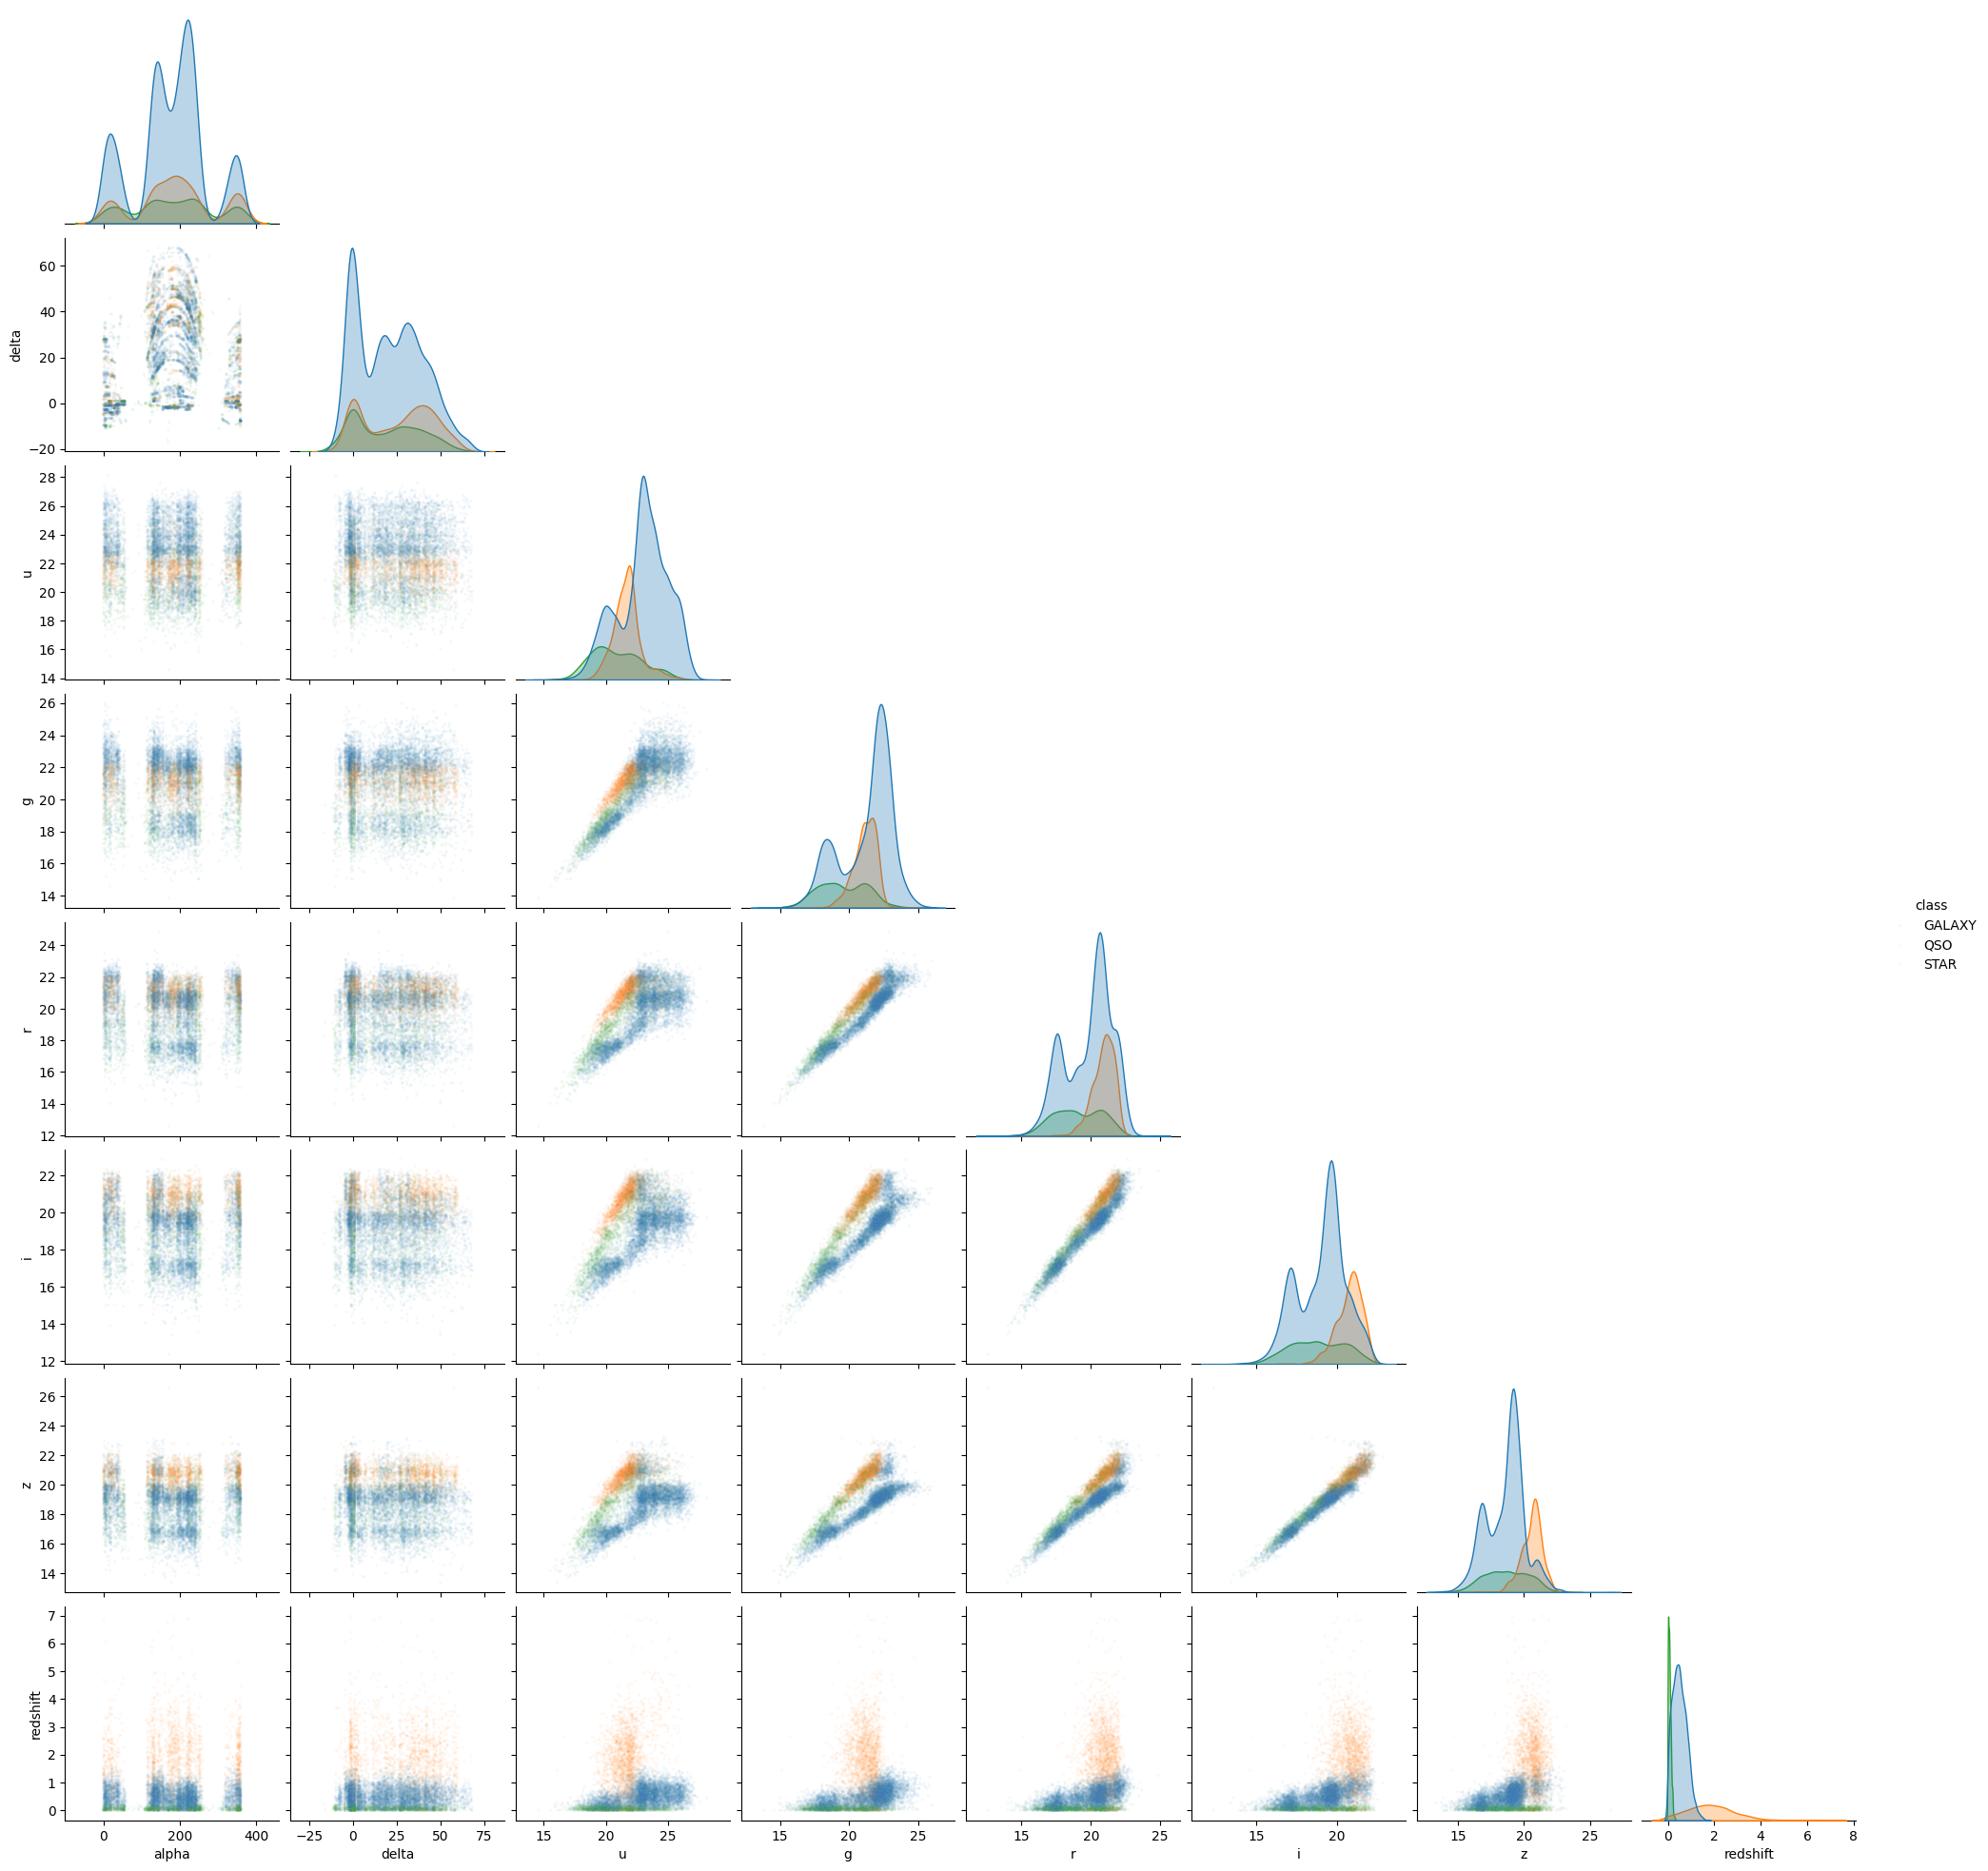

In [17]:
g = sns.pairplot(
    df_train[X_num + [y]].sample(min(10000, len(df_train)), random_state=42),
    hue=y,
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.05, "s": 5},
    diag_kws={"fill": True, "alpha": 0.3}
)

- redshift 만으로도 상당한 구분력이 있어 보인다.
- alpha의 각도인데, 3개의 봉우리이지만 각도를 shift 하면 2개의 봉우리를 지닌 분포로도 분포를 간소화 시킬 수 있어 보인다.
- u, g, r, i, z 간에는 상관도가 높아 보인다. 선형 모델로 구분이 용이해보인다.

- u의 최소값이 다른 변수에 비해 작습니다. 정렬을 해서, 이상치 인지 봅니다.

In [18]:
df_train[['u', y]].sort_values('u').iloc[:10]

,u,class
id,,
251744,-0.139225,STAR
78641,0.071698,STAR
523685,0.114522,STAR
43244,14.578353,GALAXY
66603,14.646175,GALAXY
66268,15.143665,STAR
467964,15.377486,GALAXY
35628,15.384453,GALAXY
160312,15.392808,GALAXY


In [19]:
df_test['u'].sort_values().iloc[:5]

id
764665    13.902664
678306    14.893042
718633    15.372218
659866    15.450879
691826    15.546765
Name: u, dtype: float32

- 이 변수들은 이상치일 가능성이 큽니다.

In [20]:
# STAR 일 때, 중앙값으로 치환합니다.
df_train.loc[df_train['u'] < 10, 'u'] = df_train.loc[df_train[y] == 'STAR', 'u'].median()

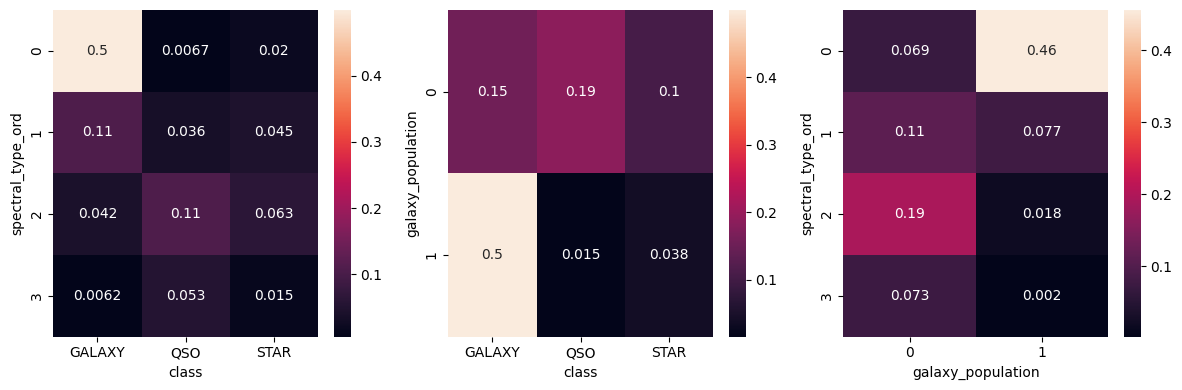

In [21]:
_, axes = plt.subplots(1, 3, figsize = (12, 4))
sns.heatmap(
    pd.crosstab(index = df_train['spectral_type_ord'], columns = df_train[y], normalize ='all'), annot=True, ax = axes[0]
)
sns.heatmap(
    pd.crosstab(index = df_train['galaxy_population'], columns = df_train[y], normalize ='all', ), annot=True, ax = axes[1]
)
sns.heatmap(
    pd.crosstab(index = df_train['spectral_type_ord'], columns = df_train['galaxy_population'], normalize ='all', ), annot=True, ax = axes[2]
)
plt.tight_layout()
plt.show()

In [22]:
df_train[['spectral_type_ord', 'galaxy_population', y]].value_counts().unstack().sort_index(level=(0, 1))

class                                GALAXY    QSO   STAR
spectral_type_ord galaxy_population                      
0                 0                   37062   1447   1597
                  1                  250961   2442   9814
1                 0                   28115  18154  17649
                  1                   33512   2767   8349
2                 0                   20316  58454  32772
                  1                    3924   3060   3596
3                 0                    3469  30219   8528
                  1                     121    600    419

- spectral_type 과 galaxy_population은 class 대한 강한 상호 작용을 지니고 있다.

- spectral_type과 galaxy_population 으로도 상당한 구분력이 있어 보입니다. 교호항까지 같이 사용하면 더 효과 있어 보입니다.

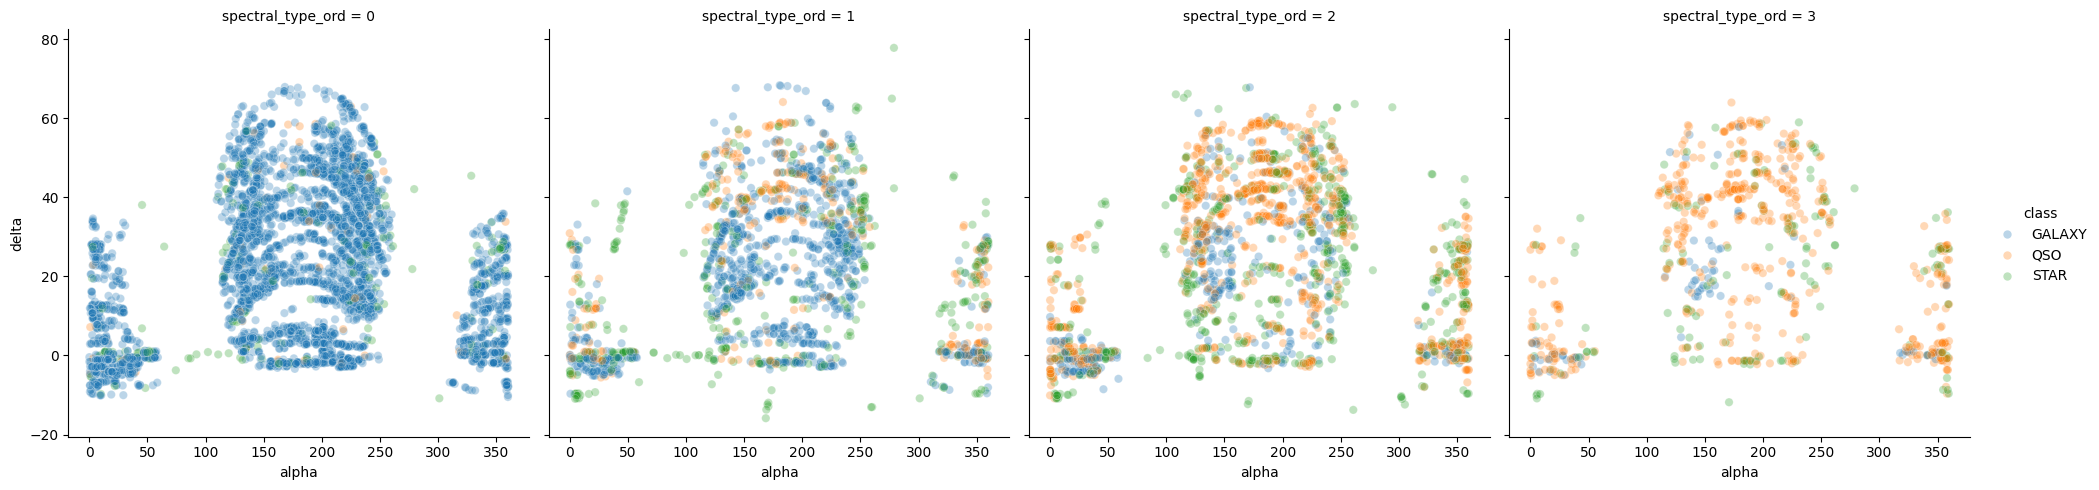

In [23]:
sns.relplot(df_train.sample(min(10000, len(df_train))), col = 'spectral_type_ord', x = 'alpha', y = 'delta', hue = y, alpha=0.3)

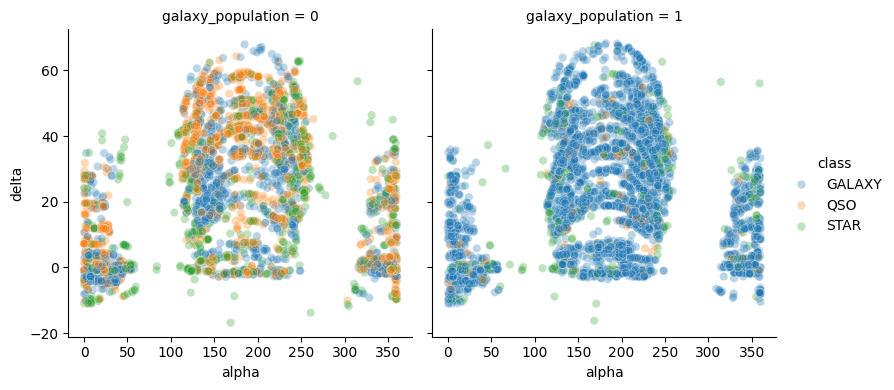

In [24]:
sns.relplot(df_train.sample(min(10000, len(df_train))), col = 'galaxy_population', x = 'alpha', y = 'delta', hue = y, alpha=0.3, height=4)

- alpha는 각도 입니다. 90를 더해서 360 의 나머지를 취해봅니다.

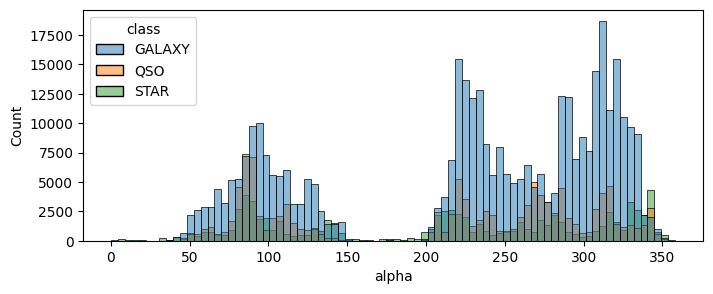

In [25]:
plt.figure(figsize = (8, 3))
sns.histplot(x=(df_train['alpha'] + 90) % 360, hue=df_train[y])
plt.show()

- 3개로 분산된 분포가 두 개로 되어 단순화 된다고 할 수 있습니다. 

In [26]:
df_train['alpha90'] = (df_train['alpha'] + 90) % 360
df_test['alpha90'] = (df_test['alpha'] + 90) % 360

- 둥일한 좌표는 동일한 분류일까?

In [27]:
df_tmp = df_train.join(
    df_train[['alpha', 'delta']].value_counts().pipe(lambda x: x.loc[x > 1]).rename('cnt'), on = ['alpha', 'delta'], how = 'inner'
)

In [28]:
df_tmp.groupby(['alpha', 'delta'])[y].apply(lambda x: x.nunique()).value_counts()

class
1    244
2     65
Name: count, dtype: int64

<Figure size 500x400 with 0 Axes>

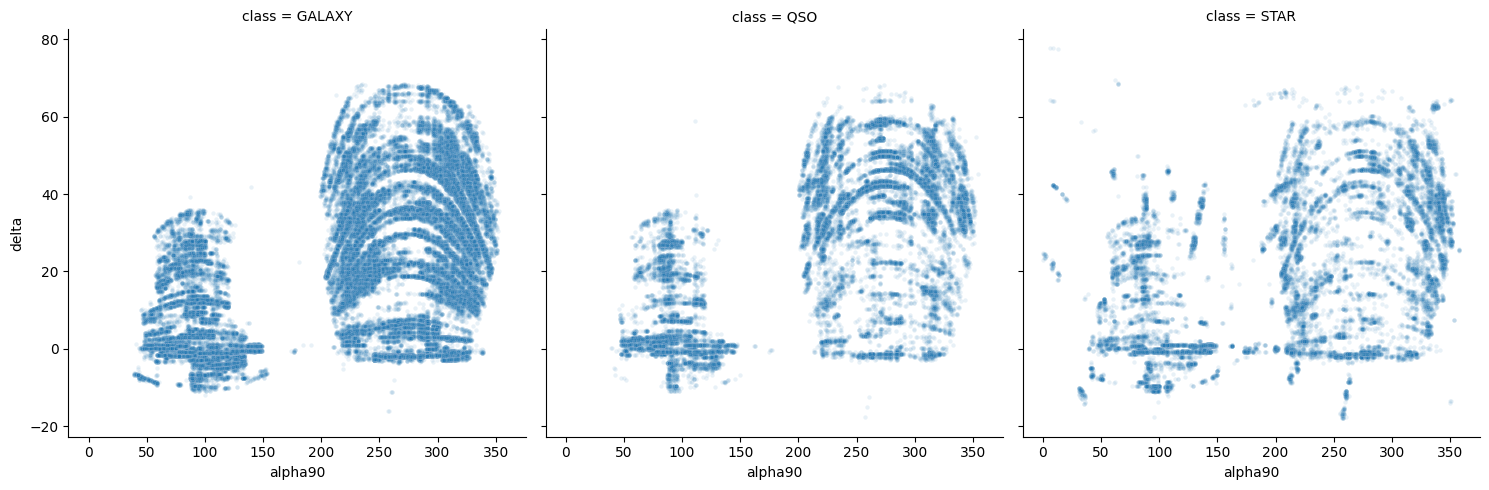

In [29]:
plt.figure(figsize = (5, 4))
sns.relplot(df_train.sample(frac=0.3), x = 'alpha90', y = 'delta', col = y, s = 10, alpha = 0.1)
plt.show()

- alpha90과, delta 결합으로 구분력이 있어 보입니다.

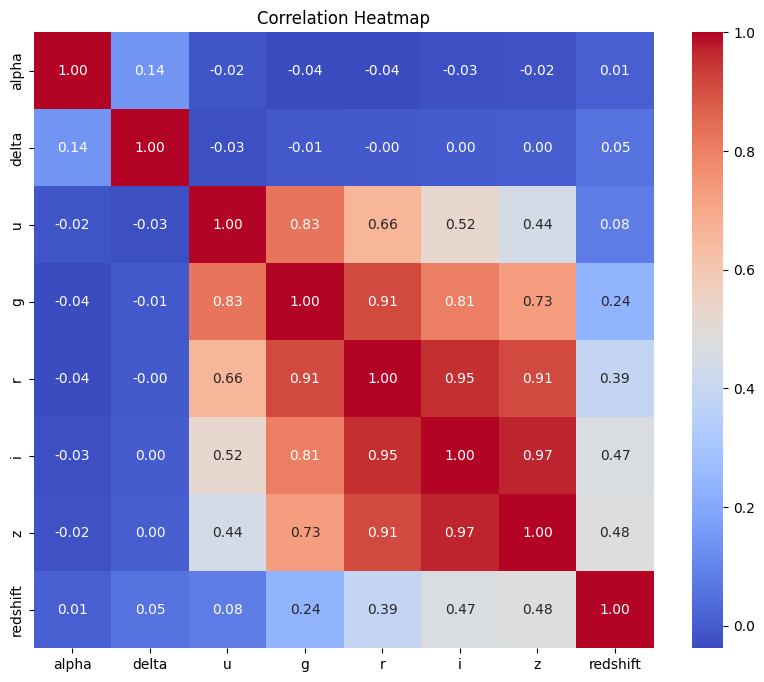

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_train[X_num].corr(), annot=True, fmt=".2f", cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

- 색상 관련된 속성은 상관도가 높다.

- 다양한 속성을 종합하여 정확도를 올리는 것이 필요해보임

# Feature Enginnering

In [31]:
# STAR 일 때, 중앙값으로 치환합니다.
df_train.loc[df_train['u'] < 10, 'u'] = df_train.loc[df_train[y] == 'STAR', 'u'].median()
df_train['alpha90'] = (df_train['alpha'] + 90) % 360
df_test['alpha90'] = (df_test['alpha'] + 90) % 360

In [32]:
# [EDA + FE + LightGBM](https://www.kaggle.com/code/nirmalpatel02/eda-fe-lightgbm) 에서 참고한 내용입니다.

X_mags = ['u', 'g', 'r', 'i', 'z']

df_train['mag_mean'] = df_train[X_mags].mean(axis=1)
df_train['mag_std'] = df_train[X_mags].std(axis=1)
df_train['mag_min'] = df_train[X_mags].min(axis=1)
df_train['mag_max'] = df_train[X_mags].max(axis=1)
df_train['mag_range'] = df_train['mag_max'] - df_train['mag_min']
df_train['mag_vmax'] = df_train[X_mags].idxmax(axis=1)

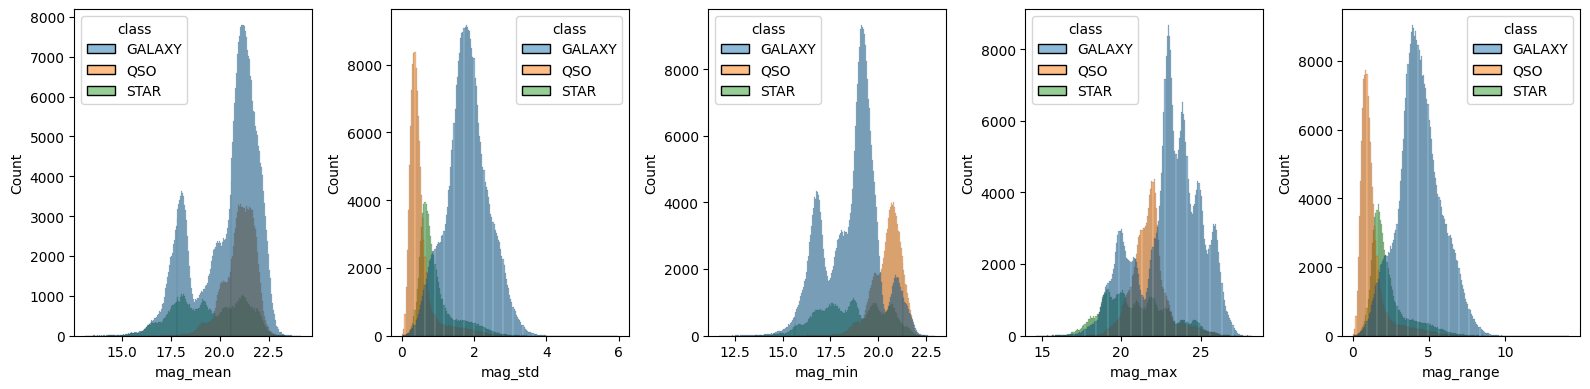

In [33]:
_, axes = plt.subplots(1, 5, figsize = (16, 4))
for i, ax in zip(['mean', 'std', 'min', 'max', 'range'], axes.flatten()):
    sns.histplot(df_train, x=f'mag_{i}', hue=y, ax = ax)
plt.tight_layout()
plt.show()

In [34]:
pd.crosstab(index=df_train['mag_vmax'], columns=df_train[y])

class,GALAXY,QSO,STAR
mag_vmax,,,
g,22629,18853,504
i,87,1714,118
r,491,5528,67
u,354008,88833,81745
z,265,2215,290


In [35]:
for i in X_mags:
    df_train['redshift_{}'.format(i)] = df_train['redshift'] * df_train[i]

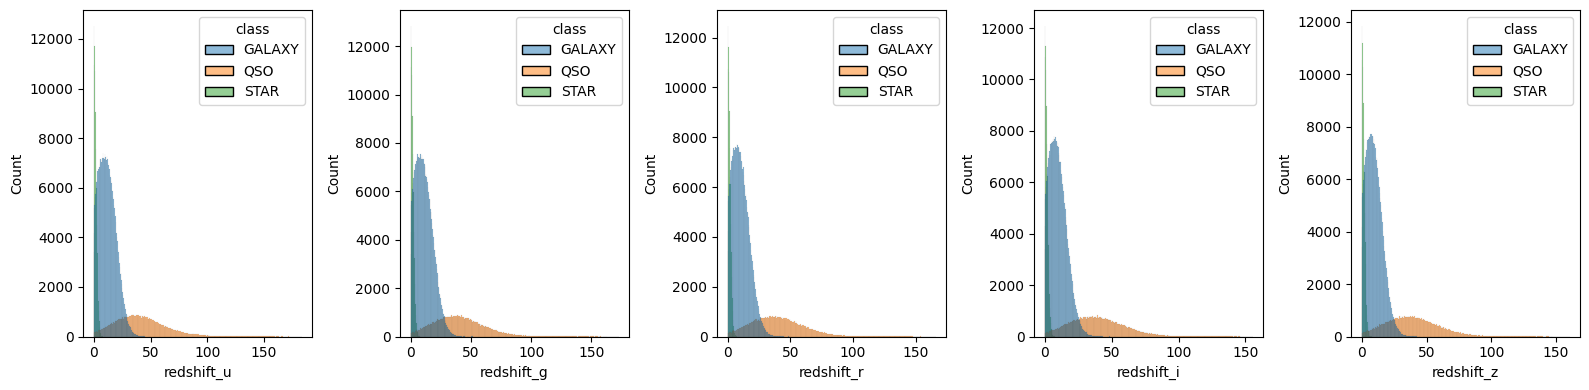

In [36]:
_, axes = plt.subplots(1, 5, figsize = (16, 4))
for i, ax in zip(X_mags, axes.flatten()):
    sns.histplot(df_train, x=f'redshift_{i}', hue=y, ax = ax)
plt.tight_layout()
plt.show()

In [37]:
df_train[[f'redshift_{i}' for i in X_mags] + ['redshift']].corr()

,redshift_u,redshift_g,redshift_r,redshift_i,redshift_z,redshift
redshift_u,1.000000,0.997766,0.996332,0.995310,0.994727,0.995847
redshift_g,0.997766,1.000000,0.999182,0.998297,0.997699,0.997824
redshift_r,0.996332,0.999182,1.000000,0.999567,0.999207,0.998370
redshift_i,0.995310,0.998297,0.999567,1.000000,0.999642,0.998327
redshift_z,0.994727,0.997699,0.999207,0.999642,1.000000,0.998168
redshift,0.995847,0.997824,0.998370,0.998327,0.998168,1.000000


In [38]:
X_mags_min = list()
for i in X_mags:
    X_mags_min.append(f'{i}_mean')
    df_train[X_mags_min[-1]] = df_train[i] - df_train['mag_mean']

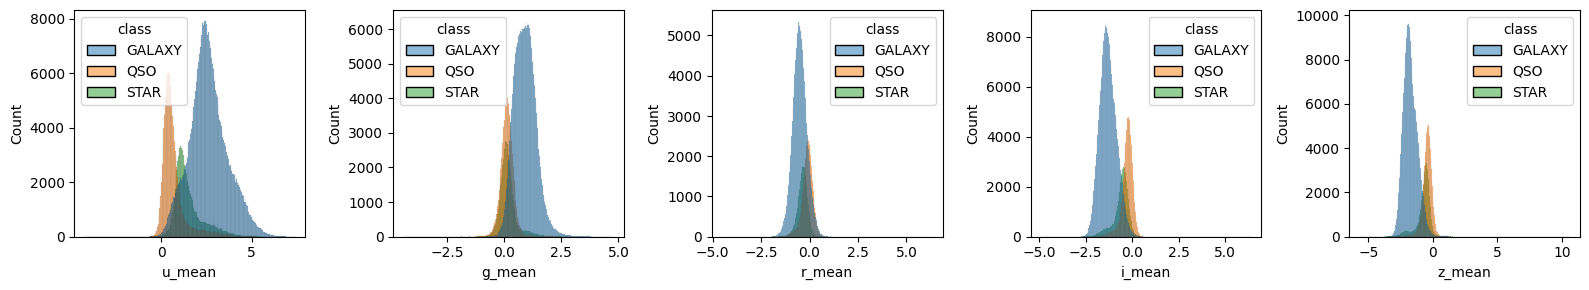

In [39]:
_, axes = plt.subplots(1, 5, figsize = (16, 3))
for i, ax in zip(X_mags, axes.flatten()):
    sns.histplot(df_train, x=f'{i}_mean', hue=y, ax = ax)
plt.tight_layout()
plt.show()

- redshift로 부터 파생된 변수의 기여는 매우 의문스럽다.

- redshift에 Log를 취해보자

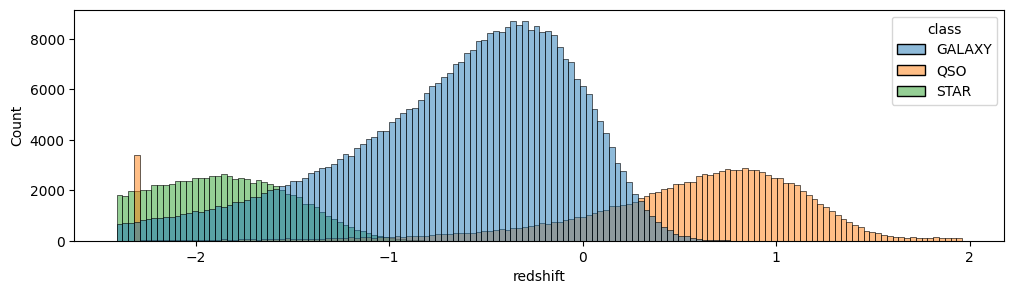

In [40]:
plt.figure(figsize = (12, 3))
sns.histplot(
    x=np.log(df_train['redshift'] + 1e-1), hue = df_train[y]
)
plt.show()

- 이러한 패턴은 binning 모델에서는 패턴을 찾기 힘들어 보인다. 그래서 log 처리한 redshift를 가져가 보자

In [41]:
df_train['log_redshift'] = np.log(df_train['redshift'] + 1e-1)
df_train.loc[df_train['redshift'] == 0.0001, y].value_counts()

class
QSO       3373
GALAXY       0
STAR         0
Name: count, dtype: int64

In [42]:
df_train['redshift_1e-4'] = df_train['redshift'] == 0.0001
df_test['redshift_1e-4'] = df_test['redshift'] == 0.0001

In [43]:
from itertools import combinations
X_diff = list()
for i, j in combinations(X_mags, 2):
    X_diff.append(f'{i}_{j}')
    df_train[X_diff[-1]] = df_train[i] - df_train[j]

In [44]:
df_train[X_diff].describe()

,u_g,u_r,u_i,u_z,g_r,g_i,g_z,r_i,r_z,i_z
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,1.434760,2.479223,3.063122,3.400897,1.044463,1.628362,1.966137,0.583900,0.921675,0.337775
std,1.140787,1.549319,1.799701,1.934317,0.736291,1.073617,1.253298,0.496787,0.675999,0.395797
min,-6.042065,-6.436968,-8.977339,-12.009587,-8.104372,-10.807922,-12.735942,-10.757963,-14.008533,-14.210768
25%,0.598522,1.200850,1.485414,1.661217,0.419983,0.634816,0.793543,0.215544,0.412939,0.094028
50%,1.333334,2.454977,3.158972,3.566980,1.075605,1.681938,2.044521,0.570047,0.913851,0.343779
75%,2.087557,3.524030,4.318819,4.780467,1.646069,2.551026,3.029281,0.946884,1.412063,0.590449
max,7.523079,9.401873,10.693436,10.407486,8.874430,9.284917,7.753952,8.749329,9.492911,7.624849


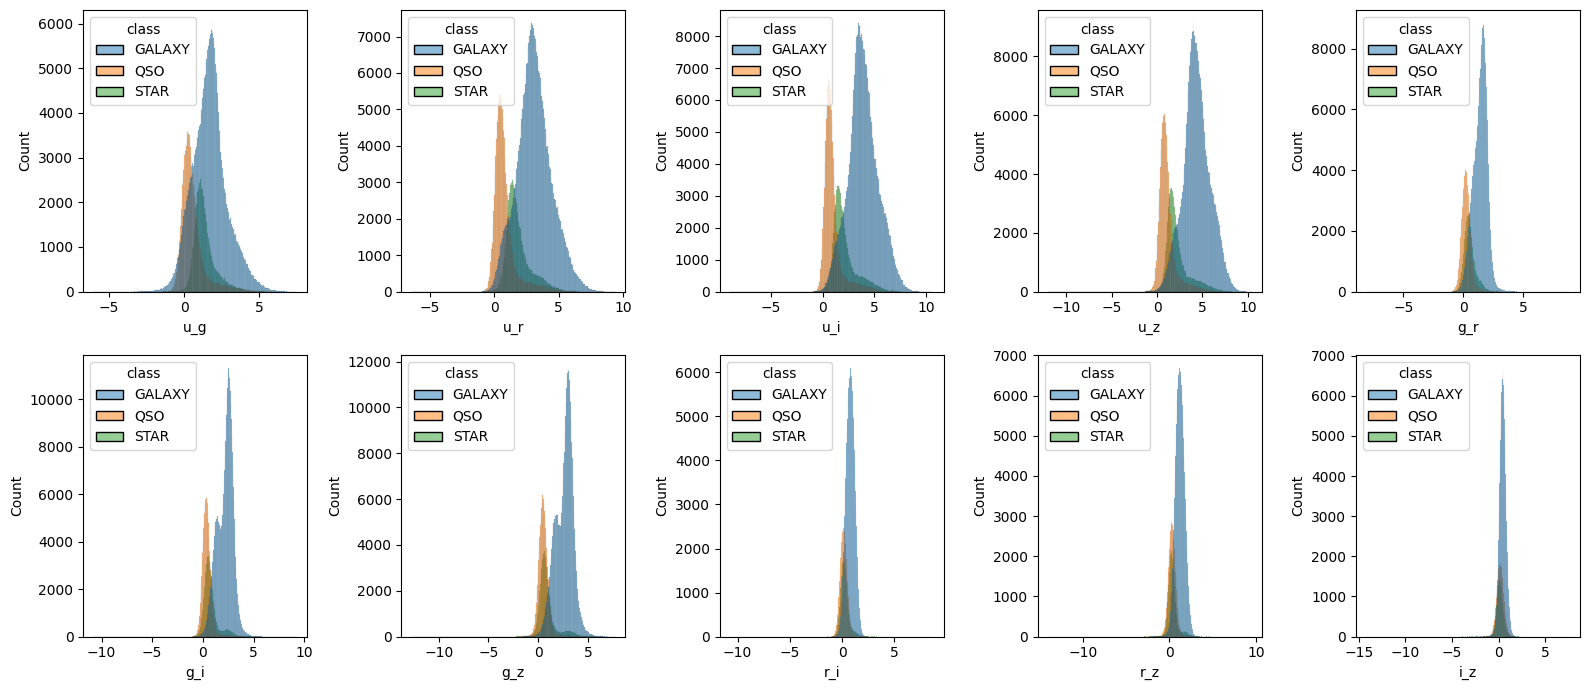

In [45]:
_, axes = plt.subplots(2, 5, figsize = (16, 7))
for i, ax in zip(X_diff, axes.flatten()):
    sns.histplot(df_train, x=i, hue=y, ax = ax)
plt.tight_layout()
plt.show()

- 공간적 밀집도가 떨어지 곳에 Star가 산개 했다 이를 이용해볼까?

<Axes: ylabel='Count'>

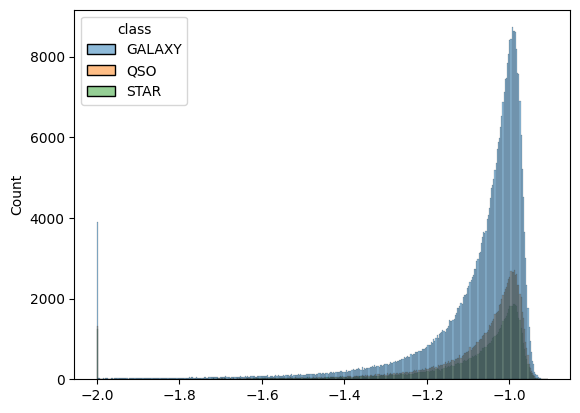

In [46]:
# Outlier Factor를 이용해보자
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor()

df_lof = pd.concat([df_train[['alpha90', 'delta']], df_test[['alpha90', 'delta']]], axis=0)
lof.fit(df_lof)
sns.histplot(
    x=lof.negative_outlier_factor_[:len(df_train)].clip(-2, 0), hue = df_train[y]
)

In [47]:
df_train['nof' ]= x=lof.negative_outlier_factor_[:len(df_train)]
df_train.groupby(y)['nof'].mean()

class
GALAXY   -1.094211
QSO      -1.097934
STAR     -1.118221
Name: nof, dtype: float32

- 공간적 상호작용을 모델링하기 위해 인접 데이터포인트를 그룹핑하기 위해 KMeans 클러스터링을 사용해봅니다.

In [48]:
def ce(val):
    return df_train[val].value_counts(normalize = True).dot(
        pd.crosstab(index = df_train[val], columns = df_train[y], normalize = 'index').apply(
            lambda x: x.dot(-np.log(x + 1e-15)), axis = 1
        )
    )

In [49]:
from sklearn.cluster import KMeans

In [50]:
clu_kmeans = KMeans(1000)
clu_kmeans.fit(df_lof)
df_train['km1000'] = clu_kmeans.labels_[:len(df_train)]
ce('km1000')

np.float64(0.6544091871973475)

In [51]:
ce('spectral_type'), ce('galaxy_population')

(np.float64(0.5798633483209699), np.float64(0.6871573828532643))

In [52]:
clu_kmeans = KMeans(2000)
clu_kmeans.fit(df_lof)
df_train['km2000'] = clu_kmeans.labels_[:len(df_train)]

In [53]:
ce('km2000')

np.float64(0.6184522067094058)

In [54]:
clu_kmeans = KMeans(500)
clu_kmeans.fit(df_lof)
df_train['km500'] = clu_kmeans.labels_[:len(df_train)]
ce('km500')

np.float64(0.6930707777497805)

In [55]:
clu_kmeans = KMeans(3000)
clu_kmeans.fit(df_lof)
df_train['km3000'] = clu_kmeans.labels_[:len(df_train)]
ce('km3000')

np.float64(0.5986887941274098)

In [56]:
df_test['km3000'] = clu_kmeans.labels_[len(df_train):]
set(df_test['km3000']) - set(df_train['km3000'])

set()

- km3000을 사용한다.

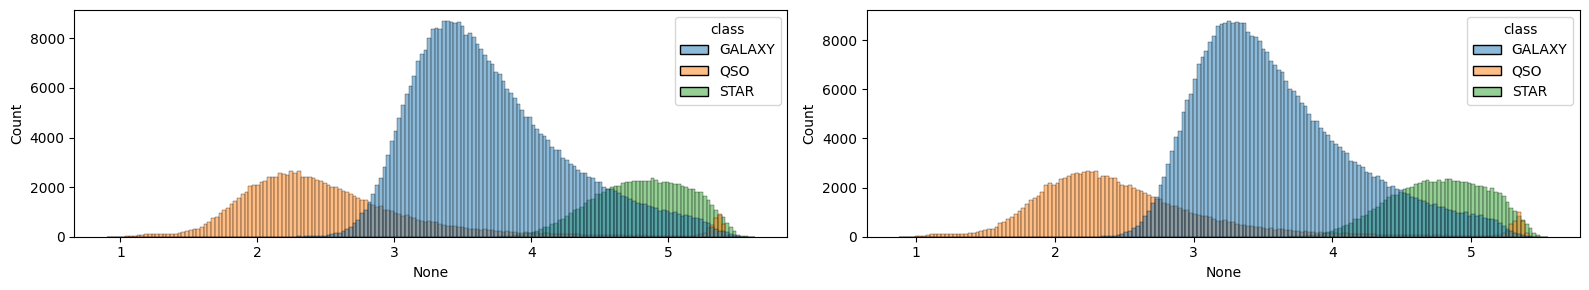

In [57]:
# [RealMLP v5 for S6E6](https://www.kaggle.com/code/cdeotte/realmlp-v5-for-s6e6)

# two redshift magnitude ratios: g/redshift and i/redshift 는 분포상 0 주위만 반짝 peak이 있고  나누기에 문제를 조잡하게 처리하고 있다.
# 그래서 log로 나타내는게 차라리 낫다고 생각 된다.
_, axes = plt.subplots(1, 2 , figsize = (16, 3))
sns.histplot(
    x = np.log(df_train['g']) - df_train['log_redshift'], hue = df_train[y], ax = axes[0]
)
sns.histplot(
    x = np.log(df_train['i']) - df_train['log_redshift'], hue = df_train[y], ax = axes[1]
)
plt.tight_layout()
plt.show()

- 신경망에서 자연스럽게 이런 속성의 조합이 이루어지도록 color feature에 모두 log 취한 속성을 넣는 게 어떨까? 

In [58]:
X_mags_log = list()
for i in X_mags:
    X_mags_log.append(f'{i}_log')
    df_train[X_mags_log[-1]] = np.log(df_train[i])

- X_mags의 선형 판변 분석을 값을 쓰는 건 어떨까?

In [59]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(df_train[X_mags], df_train[y])

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[<U6](3,)","['GALAXY','QSO','STAR']"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float32](3, 5)","[[ 0.12, 0.92, 0.3 ,-0.78,-0.86], [-0.39,-1.94,-0.72, 2.19, 1.86], [-0. ,-1.46,-0.36, 0.47, 1.31]]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If ``n_components`` is not set then all components are stored and thesum of explained variances is equal to 1.0. Only available when eigenor svd solver is used.","ndarray[float32](2,)","[0.94,0.06]"


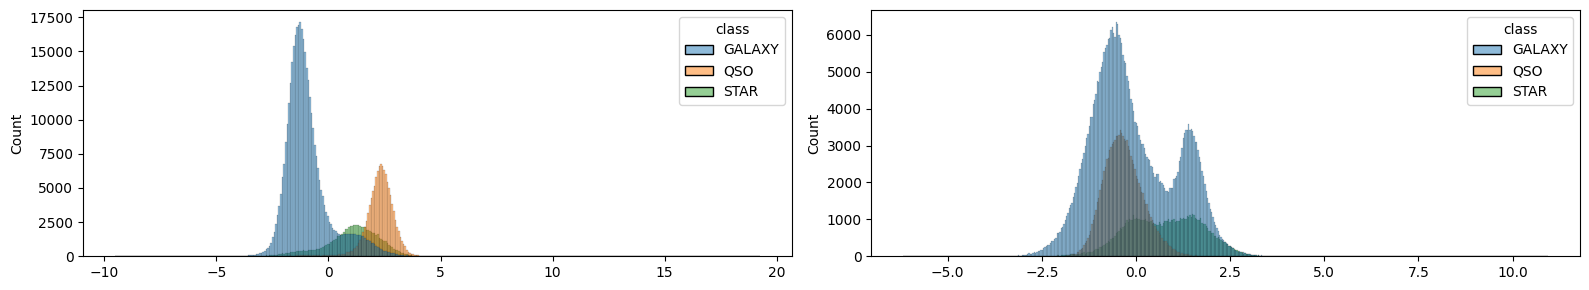

In [60]:
_, axes = plt.subplots(1, 2, figsize = (16, 3))
t = lda.transform(df_train[X_mags])
sns.histplot(x = t[:, 0], hue = df_train[y], ax = axes[0])
sns.histplot(x = t[:, 1], hue = df_train[y], ax = axes[1])
plt.tight_layout()
plt.show()